# 02 — Spectrograms and Short-Time Fourier Transform

In the previous notebook, we explored audio signals in the time domain using waveforms.

However, many important properties of sound are related to **frequency content**.

In this notebook, we will introduce the basic intuition behind:

1. Fourier Transform
2. Discrete Fourier Transform
3. Fast Fourier Transform
4. Short-Time Fourier Transform
5. Spectrograms

The goal is not to derive the full mathematical theory, but to understand what these tools allow us to see in audio signals.

A useful idea is:

```text
waveform     → what happens over time
spectrum     → what frequencies are present
spectrogram  → what frequencies are present over time
```

## Learning goals

By the end of this notebook, you should be able to explain:

- why a waveform is sometimes not enough to understand an audio signal;
- what information is shown by a spectrum;
- the difference between the DFT and the FFT;
- why we need the Short-Time Fourier Transform;
- how a spectrogram represents audio in time and frequency.

In [1]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display

In [2]:
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBSET_METADATA = PROJECT_ROOT / "data" / "processed" / "esc50_subset" / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Metadata exists:", SUBSET_METADATA.exists())

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Metadata exists: True


## Why do we need the frequency domain?

A waveform tells us how the amplitude of the signal changes over time.

This is useful, but it does not always tell us directly which frequencies are present in the sound.

For example, two signals may look complicated in the time domain, but their frequency content may be simple.

Fourier analysis helps us ask a different question:

> What frequencies are present in this signal?

## Pure tone in the time domain

A pure tone is one of the simplest audio signals.

It can be represented as a sinusoidal signal:

$$
x(t) = A \sin(2 \pi f t)
$$

where:

- $A$ is the amplitude,
- $f$ is the sound frequency in Hz,
- $t$ is time in seconds.

After sampling, we obtain a digital signal:

$$
x[n] = A \sin\left(2 \pi f \frac{n}{f_s}\right)
$$

where $f_s$ is the sampling rate.

In [3]:
sampling_rate = 22050  # samples per second
sound_frequency = 440  # Hz
duration_s = 1.0
amplitude = 0.8

t = np.arange(0, duration_s, 1 / sampling_rate)
x = amplitude * np.sin(2 * np.pi * sound_frequency * t)

print("Sampling rate:", sampling_rate, "Hz")
print("Sound frequency:", sound_frequency, "Hz")
print("Duration:", duration_s, "seconds")
print("Number of samples:", len(x))

Sampling rate: 22050 Hz
Sound frequency: 440 Hz
Duration: 1.0 seconds
Number of samples: 22050


In [4]:
display(Audio(x, rate=sampling_rate))

## Waveform of a pure tone

At 440 Hz, the signal oscillates 440 times per second.

If we plot the full second, the oscillations are too dense to inspect visually. Therefore, we plot only a short time window.

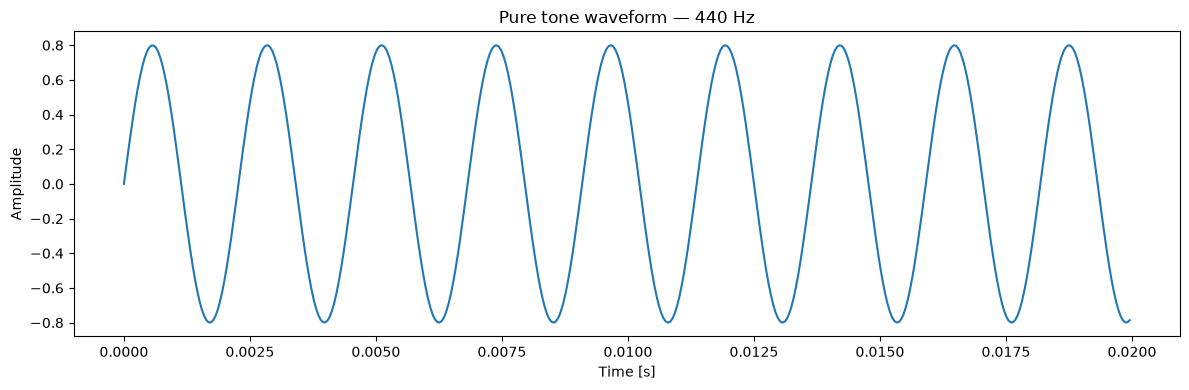

In [5]:
time_window = 0.02  # seconds
samples_to_plot = int(time_window * sampling_rate)

plt.figure(figsize=(12, 4))
plt.plot(t[:samples_to_plot], x[:samples_to_plot])
plt.title("Pure tone waveform — 440 Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## From waveform to spectrum

The Fourier Transform represents a signal in terms of frequency components.

For a digital signal, we use the **Discrete Fourier Transform**.

The Discrete Fourier Transform maps a discrete-time signal $x[n]$ into a frequency-domain representation $X[k]$:

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2 \pi kn/N}
$$

In practical terms, $X[k]$ tells us how much of each frequency component is present in the signal.

The **Fast Fourier Transform** is an efficient algorithm to compute the DFT.

In Python, we can use:

```python
np.fft.rfft(x)
np.fft.rfftfreq(N, d=1/fs)
```

where:

- `np.fft.rfft(x)` computes the FFT for a real-valued signal,
- `np.fft.rfftfreq(...)` gives the frequency values associated with the FFT bins.

## FFT of a pure tone

A pure tone should produce one dominant peak in the spectrum.

Since our signal has a frequency of 440 Hz, we expect a peak near 440 Hz.

In [6]:
N = len(x)
fft_values = np.fft.rfft(x)
fft_magnitude = np.abs(fft_values)
frequencies = np.fft.rfftfreq(N, d=1 / sampling_rate)

peak_index = np.argmax(fft_magnitude)
peak_frequency = frequencies[peak_index]

print("Peak frequency:", peak_frequency, "Hz")

Peak frequency: 440.0 Hz


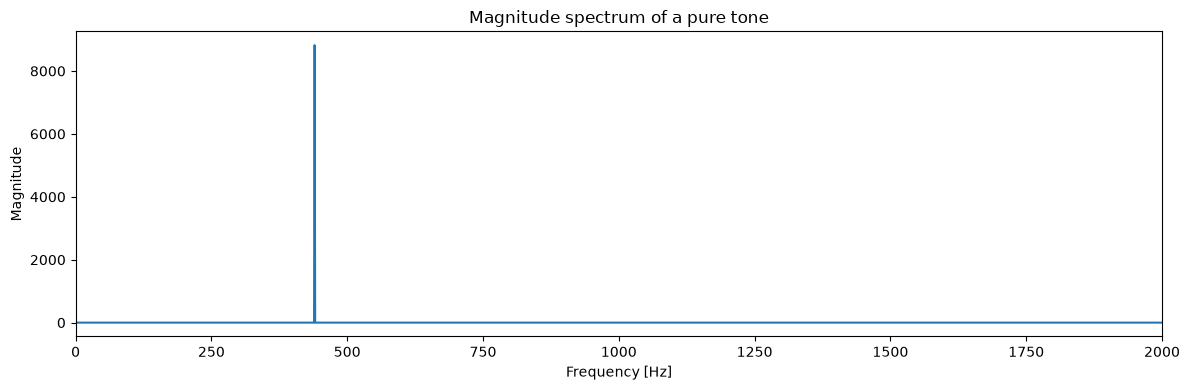

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(frequencies, fft_magnitude)
plt.title("Magnitude spectrum of a pure tone")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

### Interpretation

The spectrum has one dominant peak close to 440 Hz.

This shows that a pure sinusoidal tone contains one dominant frequency component.

## Signal with multiple frequencies

Real sounds are usually more complex than a single pure tone.

To illustrate this, we can create a synthetic signal by adding several pure tones:

$$
x(t) = x_1(t) + x_2(t) + x_3(t)
$$

In this example, we combine 440 Hz, 880 Hz, and 1760 Hz.

In [8]:
frequencies_hz = [440, 880, 1760]
amplitudes = [0.8, 0.5, 0.3]

multi_tone = np.zeros_like(t)

for frequency, amp in zip(frequencies_hz, amplitudes):
    multi_tone += amp * np.sin(2 * np.pi * frequency * t)

# Normalize to avoid clipping in playback.
multi_tone = multi_tone / np.max(np.abs(multi_tone)) * 0.8

print("Frequencies:", frequencies_hz)
print("Duration:", duration_s, "seconds")
print("Number of samples:", len(multi_tone))

Frequencies: [440, 880, 1760]
Duration: 1.0 seconds
Number of samples: 22050


In [9]:
display(Audio(multi_tone, rate=sampling_rate))

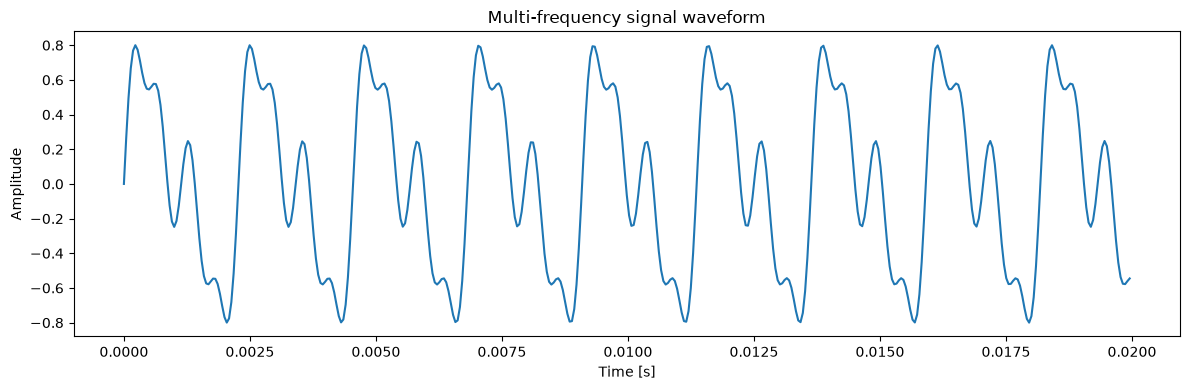

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(t[:samples_to_plot], multi_tone[:samples_to_plot])
plt.title("Multi-frequency signal waveform")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## FFT of a multi-frequency signal

The waveform is now more complex, but the spectrum should reveal the frequencies used to construct the signal.

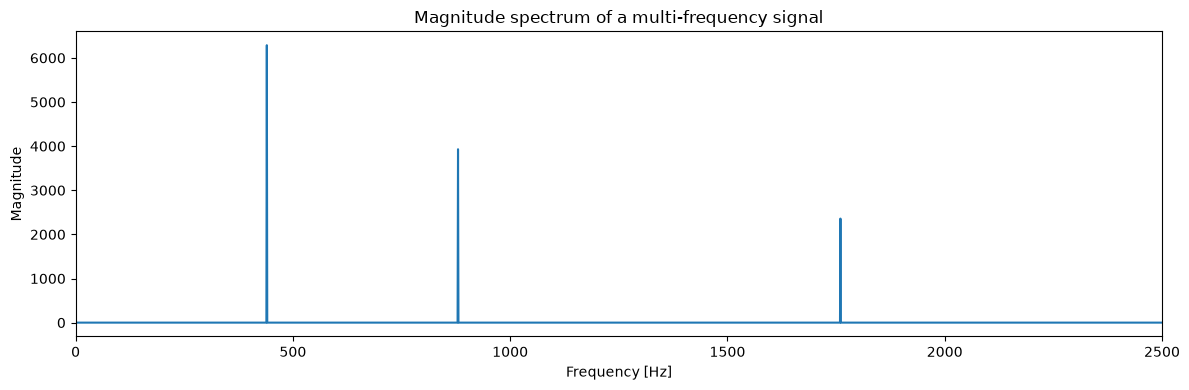

In [11]:
N = len(multi_tone)
fft_values = np.fft.rfft(multi_tone)
fft_magnitude = np.abs(fft_values)
frequencies = np.fft.rfftfreq(N, d=1 / sampling_rate)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, fft_magnitude)
plt.title("Magnitude spectrum of a multi-frequency signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.xlim(0, 2500)
plt.tight_layout()
plt.show()

### Interpretation

The FFT reveals several peaks corresponding to the frequency components of the signal.

This is the first key idea:

> The waveform may look complex, but the spectrum can reveal its frequency structure.

## Limitation of the global FFT

The FFT tells us what frequencies are present in the signal, but it does not tell us when they occur.

This becomes a problem when the frequency content changes over time.

To illustrate this, we will create a signal with three time segments:

1. first segment: 440 Hz,
2. second segment: 880 Hz,
3. third segment: 1760 Hz.

In [12]:
segment_duration = 1.0
segment_t = np.arange(0, segment_duration, 1 / sampling_rate)

segment_1 = np.sin(2 * np.pi * 440 * segment_t)
segment_2 = np.sin(2 * np.pi * 880 * segment_t)
segment_3 = np.sin(2 * np.pi * 1760 * segment_t)

changing_signal = np.concatenate([segment_1, segment_2, segment_3])
changing_signal = 0.8 * changing_signal / np.max(np.abs(changing_signal))

changing_duration = len(changing_signal) / sampling_rate
changing_t = np.arange(len(changing_signal)) / sampling_rate

print("Duration:", changing_duration, "seconds")
print("Number of samples:", len(changing_signal))

Duration: 3.0 seconds
Number of samples: 66150


In [13]:
display(Audio(changing_signal, rate=sampling_rate))

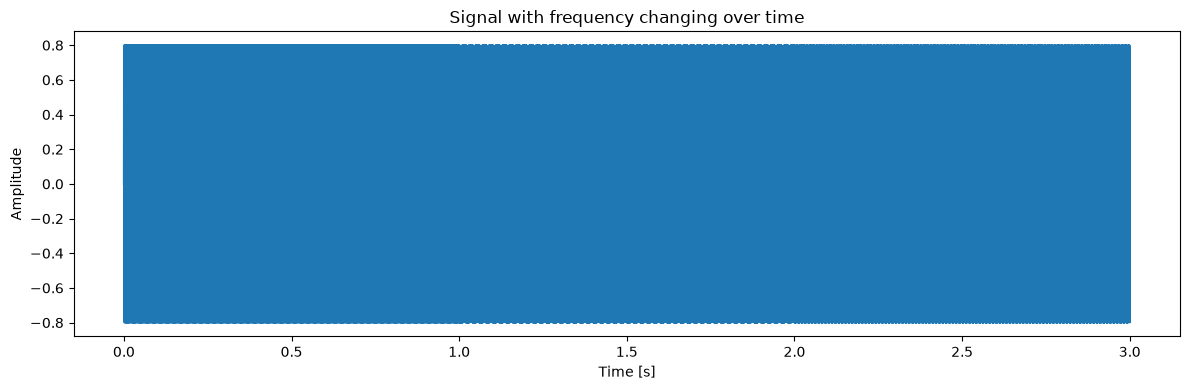

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(changing_t, changing_signal)
plt.title("Signal with frequency changing over time")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Global FFT of a changing signal

The global FFT analyzes the entire signal at once.

It can identify that the signal contains 440 Hz, 880 Hz, and 1760 Hz, but it does not directly show when each frequency occurs.

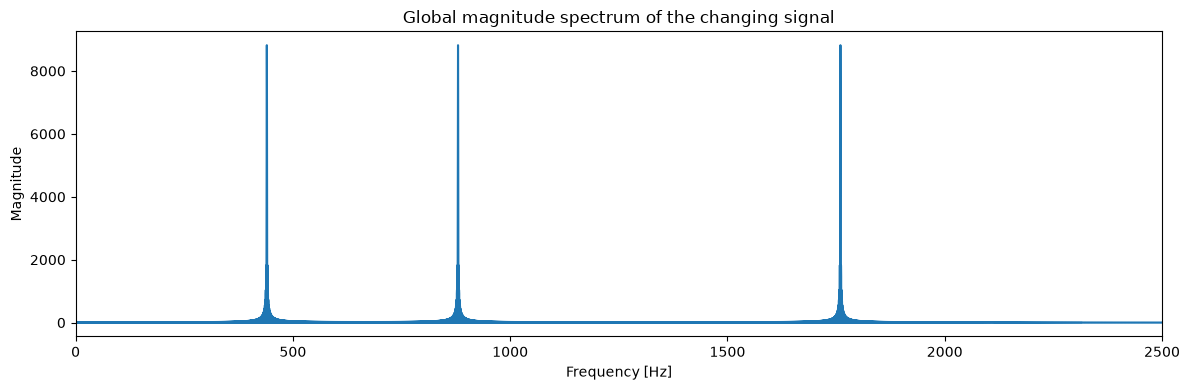

In [15]:
N = len(changing_signal)
fft_values = np.fft.rfft(changing_signal)
fft_magnitude = np.abs(fft_values)
frequencies = np.fft.rfftfreq(N, d=1 / sampling_rate)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, fft_magnitude)
plt.title("Global magnitude spectrum of the changing signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.xlim(0, 2500)
plt.tight_layout()
plt.show()

### Key limitation

The global spectrum tells us:

```text
The signal contains 440 Hz, 880 Hz, and 1760 Hz.
```

But it does not clearly tell us:

```text
440 Hz occurs first, 880 Hz occurs second, and 1760 Hz occurs third.
```

To recover this temporal information, we need a time-frequency representation.

## Short-Time Fourier Transform

The **Short-Time Fourier Transform** applies the Fourier Transform to short overlapping windows of the signal.

Instead of analyzing the entire signal at once, the STFT analyzes small time regions.

Conceptually:

```text
whole signal → short window → FFT
             → next window  → FFT
             → next window  → FFT
             → ...
```

The result tells us how the frequency content changes over time.

## STFT parameters

The main STFT parameters are:

- `n_fft`: size of the FFT window;
- `hop_length`: number of samples between consecutive windows;
- `window`: shape of the analysis window.

A useful intuition:

```text
larger window  → better frequency resolution, poorer time resolution
smaller window → better time resolution, poorer frequency resolution
```

This is one of the central trade-offs in time-frequency analysis.

## Visual intuition: sliding windows

The next figure illustrates the main idea of the STFT: we analyze short portions of the signal using overlapping windows.

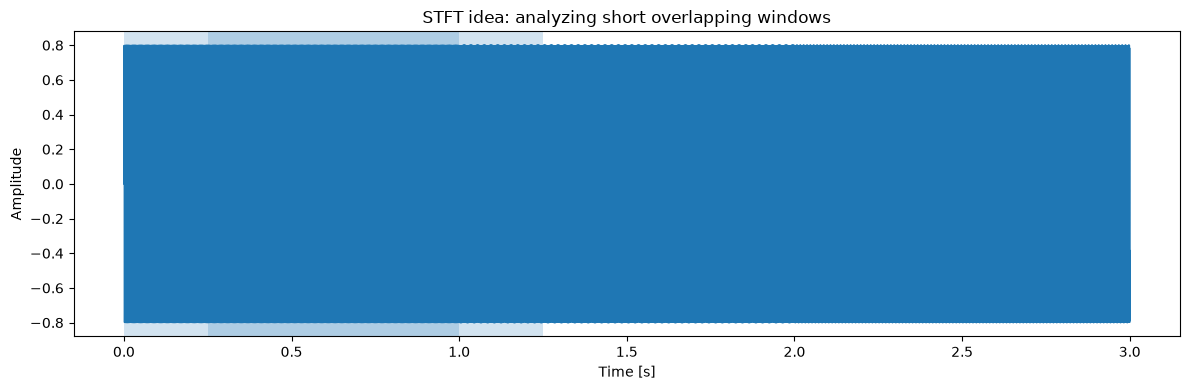

In [16]:
# Simple conceptual visualization of sliding analysis windows.
window_length_s = 0.5
hop_s = 0.25

window_length_samples = int(window_length_s * sampling_rate)
hop_samples = int(hop_s * sampling_rate)

plt.figure(figsize=(12, 4))
plt.plot(changing_t, changing_signal, linewidth=1)

start_samples = [0, hop_samples, 2 * hop_samples, 3 * hop_samples]

for start in start_samples:
    end = start + window_length_samples
    start_time = start / sampling_rate
    end_time = end / sampling_rate
    plt.axvspan(start_time, end_time, alpha=0.2)

plt.title("STFT idea: analyzing short overlapping windows")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Spectrogram of the changing signal

A spectrogram is a visual representation of the STFT magnitude.

It shows:

- time on the x-axis,
- frequency on the y-axis,
- magnitude or energy using color.

In other words:

```text
spectrogram = how frequency content changes over time
```

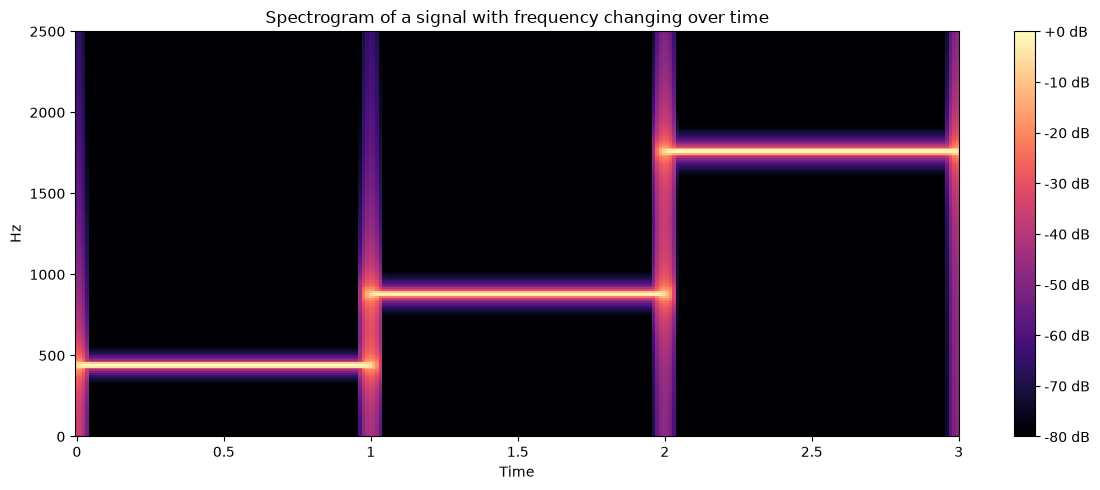

In [17]:
n_fft = 2048
hop_length = 256

S = librosa.stft(changing_signal, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sampling_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram of a signal with frequency changing over time")
plt.ylim(0, 2500)
plt.tight_layout()
plt.show()

### Interpretation

The spectrogram shows when each frequency occurs:

- the first segment contains approximately 440 Hz,
- the second segment contains approximately 880 Hz,
- the third segment contains approximately 1760 Hz.

This is the central advantage of the spectrogram:

> It shows frequency content as a function of time.

## Load a real audio example from ESC-50

Now we will compute the spectrogram of a real environmental sound from the ESC-50 subset.

In [18]:
metadata = pd.read_csv(SUBSET_METADATA)

selected_category = "chirping_birds"
example = metadata[metadata["category"] == selected_category].iloc[0]

audio_path = PROJECT_ROOT / example["subset_audio_path"]

y, sr = librosa.load(audio_path, sr=None, mono=True)
duration = librosa.get_duration(y=y, sr=sr)

print("Selected category:", selected_category)
print("Filename:", example["filename"])
print("Sampling rate:", sr, "Hz")
print("Number of samples:", len(y))
print("Duration:", duration, "seconds")

Selected category: chirping_birds
Filename: 1-100038-A-14.wav
Sampling rate: 44100 Hz
Number of samples: 220500
Duration: 5.0 seconds


In [19]:
display(Audio(y, rate=sr))

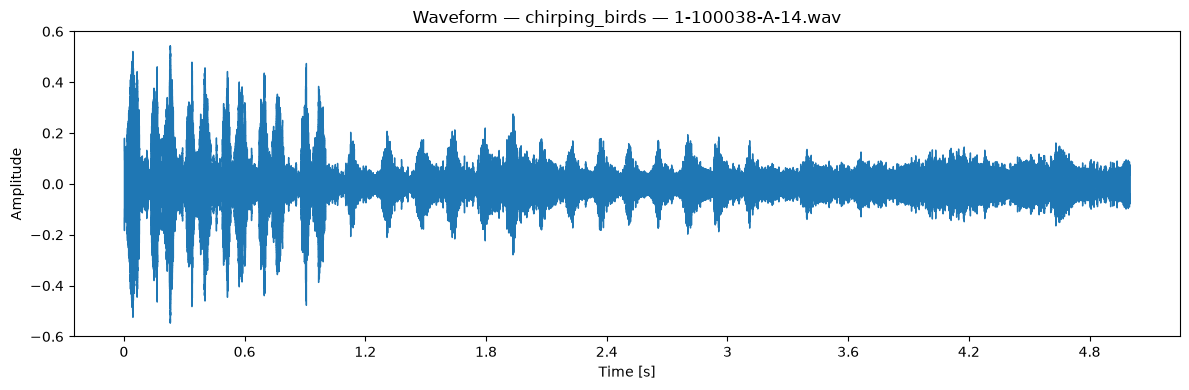

In [20]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform — {example['category']} — {example['filename']}")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Spectrogram of a real audio file

We now apply the STFT to the real audio example.

This allows us to see how its frequency content changes over time.

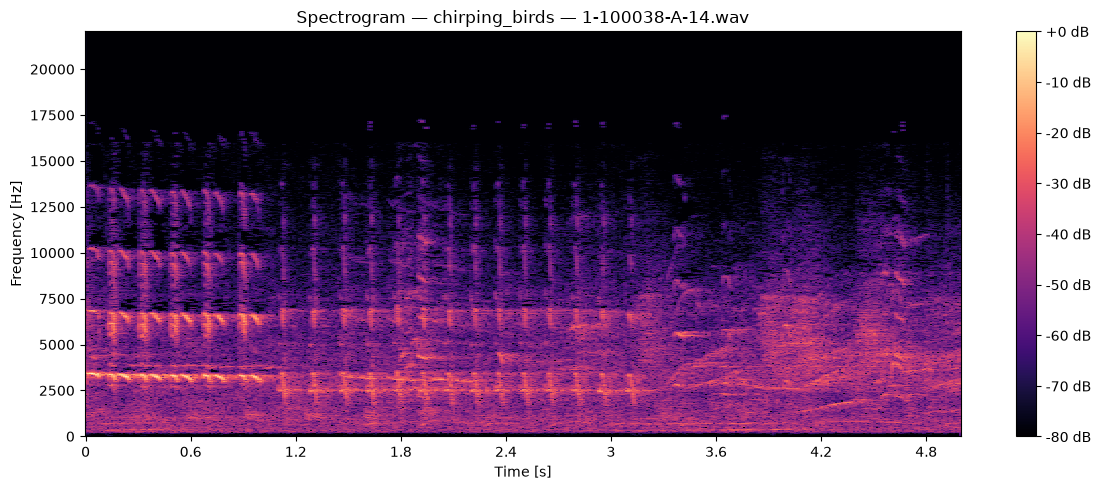

In [21]:
n_fft = 2048
hop_length = 512

S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram — {example['category']} — {example['filename']}")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

## Compare spectrograms from different classes

Different sound classes may have different time-frequency patterns.

For example:

- `rain` may look more continuous and broadband;
- `clock_tick` may show short impulsive events;
- `chirping_birds` may show narrow frequency components that change over time;
- `helicopter` may show lower-frequency periodic structure.

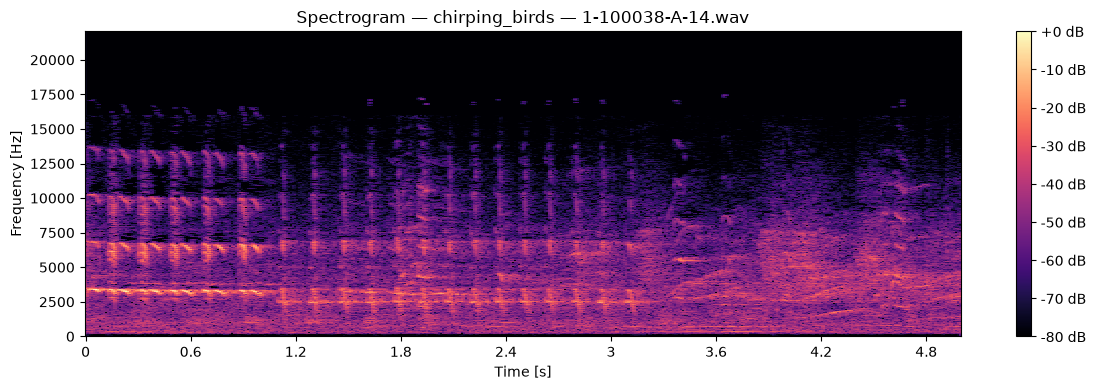

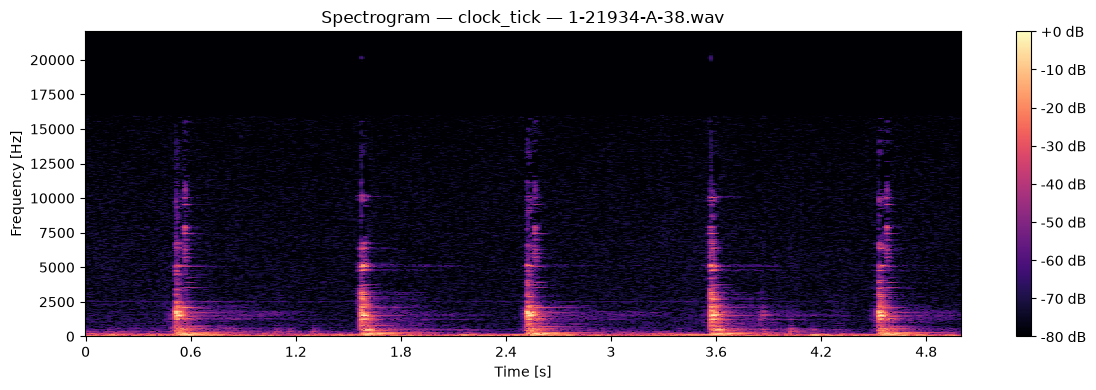

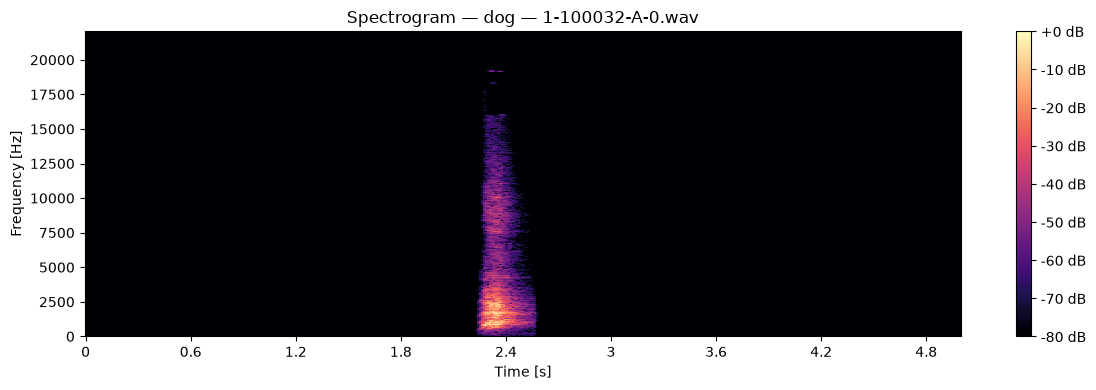

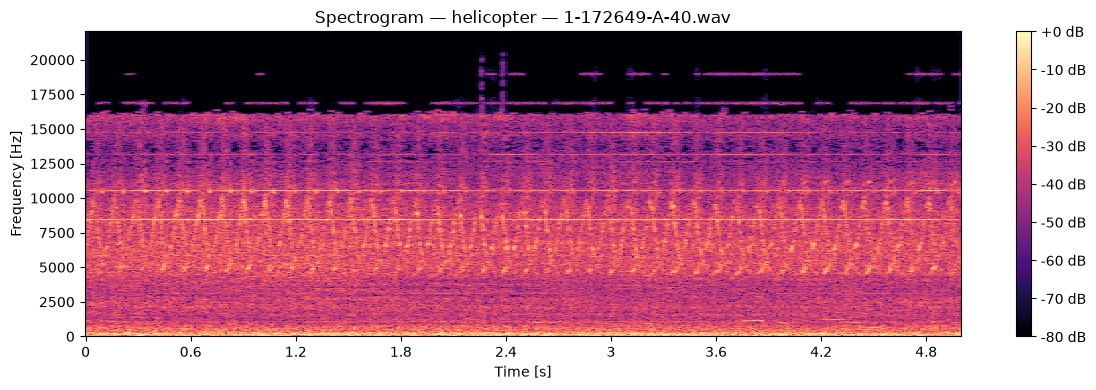

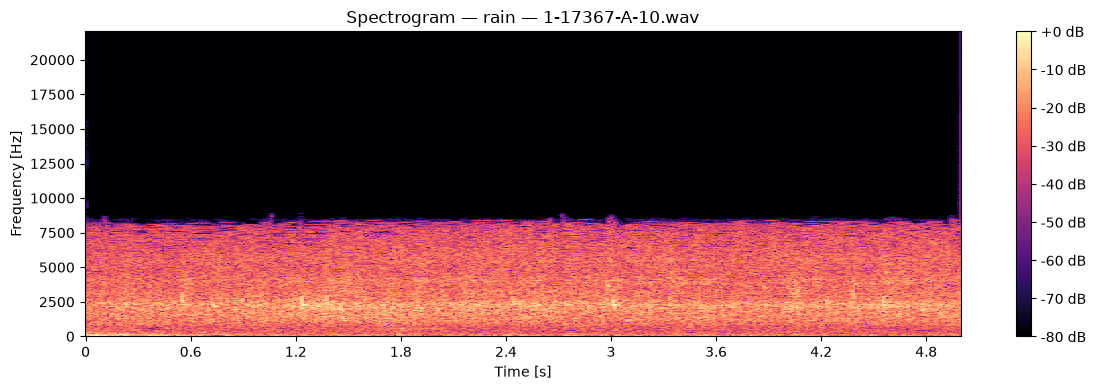

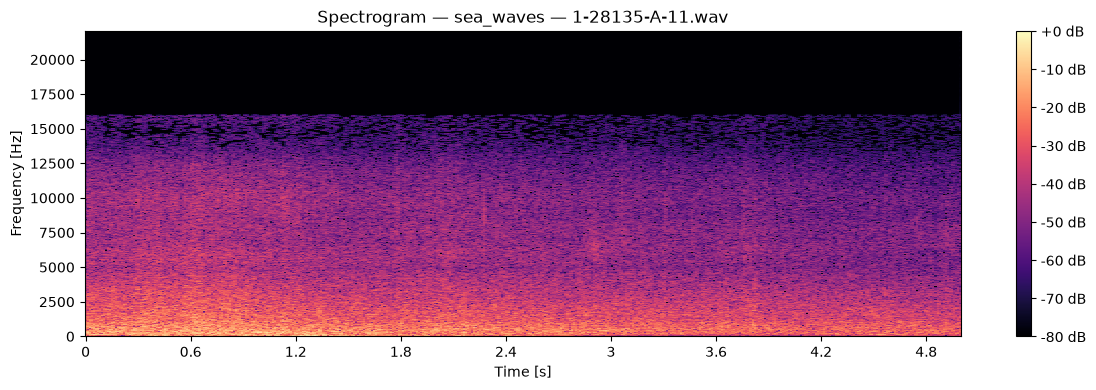

In [22]:
selected_categories = [
    "chirping_birds",
    "clock_tick",
    "dog",
    "helicopter",
    "rain",
    "sea_waves",
]

for category in selected_categories:
    row = metadata[metadata["category"] == category].iloc[0]
    audio_path = PROJECT_ROOT / row["subset_audio_path"]

    y_tmp, sr_tmp = librosa.load(audio_path, sr=None, mono=True)

    S = librosa.stft(y_tmp, n_fft=2048, hop_length=512)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_db,
        sr=sr_tmp,
        hop_length=512,
        x_axis="time",
        y_axis="hz",
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Spectrogram — {category} — {row['filename']}")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.tight_layout()
    plt.show()

## Summary

In this notebook, we moved from time-domain analysis to time-frequency analysis.

Key ideas:

- A waveform shows how the signal amplitude changes over time.
- A spectrum shows which frequencies are present in the signal.
- The DFT is the discrete version of the Fourier Transform for digital signals.
- The FFT is an efficient algorithm to compute the DFT.
- The global FFT does not show when frequencies occur.
- The STFT applies the FFT to short time windows.
- A spectrogram visualizes how frequency content changes over time.

## Discussion questions

1. Why is the waveform not always enough to understand an audio signal?
2. What does a peak in the magnitude spectrum represent?
3. What information is lost when using a global FFT?
4. Why does the STFT use short overlapping windows?
5. How do the spectrograms differ across sound classes?
6. Which classes look more impulsive, tonal, or broadband in the spectrogram?